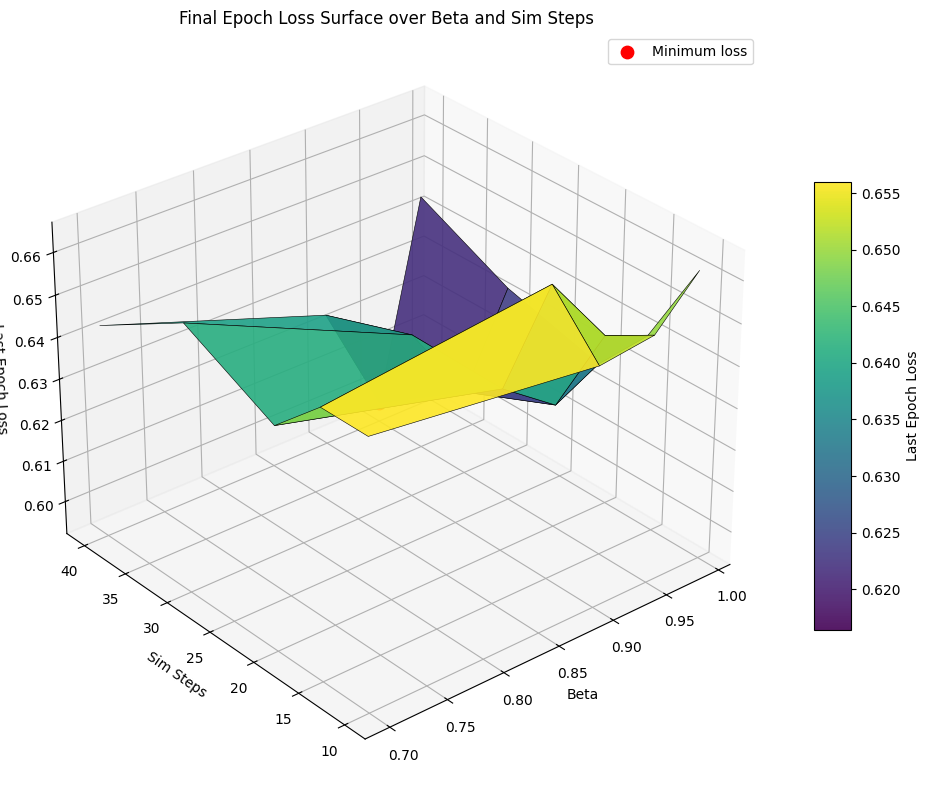

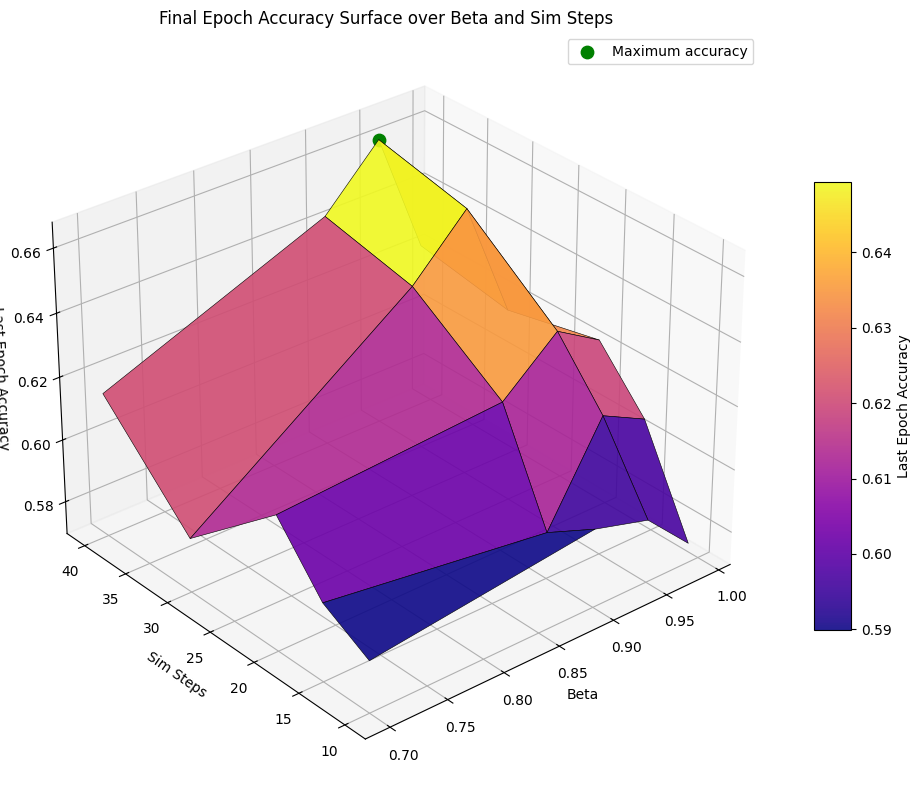

=== Best Parameter Combination (Minimum Last-Epoch Loss) ===
Beta: 0.95
Sim Steps: 40
Last Epoch Loss: 0.596758
File: hypr_2026-04-26_16-49-15_e-10_s-40_spatial.json

=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===
Beta: 0.95
Sim Steps: 40
Last Epoch Accuracy: 0.661600
File: hypr_2026-04-26_16-49-15_e-10_s-40_spatial.json

Accuracy key(s) used: ['epoch_train_accuracy']


In [6]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Build 3D surfaces of final-epoch metrics over (beta, sim_steps).
import numpy as np

files = sorted(glob('../output_results/E2/hypr/hypr_*.json'))
if not files:
    raise FileNotFoundError('No matching files found in ../output_results/E2')

# (beta, sim_steps, last_epoch_loss, last_epoch_accuracy, file_name, acc_key_used)
records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    beta_raw = training_config.get('beta')
    sim_steps_raw = training_config.get('sim_steps')
    epoch_losses = results.get('epoch_train_loss', [])

    accuracy_key_candidates = [
        'epoch_train_accuracy',
        'epoch_accuracy',
        'epoch_val_accuracy',
        'epoch_test_accuracy',
    ]
    last_acc = None
    acc_key_used = None
    for key in accuracy_key_candidates:
        series = results.get(key, [])
        if isinstance(series, list) and series:
            last_acc = float(series[-1])
            acc_key_used = key
            break

    if beta_raw is None or sim_steps_raw is None or not epoch_losses or last_acc is None:
        continue

    beta = float(beta_raw)
    sim_steps = float(sim_steps_raw)
    last_epoch_loss = float(epoch_losses[-1])
    records.append((beta, sim_steps, last_epoch_loss, last_acc, Path(file).name, acc_key_used))

if not records:
    raise ValueError(
        'No valid records found with beta, sim_steps, epoch_train_loss, and an accuracy series.'
    )

betas = sorted({r[0] for r in records})
sim_steps_vals = sorted({r[1] for r in records})

# Create rectangular grids for both surfaces.
X, Y = np.meshgrid(betas, sim_steps_vals)
Z_loss = np.full_like(X, np.nan, dtype=float)
Z_acc = np.full_like(X, np.nan, dtype=float)

for beta, sim_steps, loss, acc, _, _ in records:
    x_idx = betas.index(beta)
    y_idx = sim_steps_vals.index(sim_steps)
    Z_loss[y_idx, x_idx] = loss
    Z_acc[y_idx, x_idx] = acc

fig1 = plt.figure(figsize=(11, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surface_loss = ax1.plot_surface(
    X, Y, Z_loss, cmap='viridis', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig1.colorbar(surface_loss, ax=ax1, shrink=0.6, aspect=12, label='Last Epoch Loss')

best_beta, best_sim_steps, best_loss, _, best_loss_file, _ = min(records, key=lambda x: x[2])
ax1.scatter(best_beta, best_sim_steps, best_loss, color='red', s=80, label='Minimum loss')
ax1.legend()

ax1.set_title('Final Epoch Loss Surface over Beta and Sim Steps')
ax1.set_xlabel('Beta')
ax1.set_ylabel('Sim Steps')
ax1.set_zlabel('Last Epoch Loss')
ax1.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(11, 8))
ax2 = fig2.add_subplot(111, projection='3d')
surface_acc = ax2.plot_surface(
    X, Y, Z_acc, cmap='plasma', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig2.colorbar(surface_acc, ax=ax2, shrink=0.6, aspect=12, label='Last Epoch Accuracy')

best_beta_acc, best_sim_steps_acc, _, best_acc, best_acc_file, _ = max(records, key=lambda x: x[3])
ax2.scatter(best_beta_acc, best_sim_steps_acc, best_acc, color='green', s=80, label='Maximum accuracy')
ax2.legend()

ax2.set_title('Final Epoch Accuracy Surface over Beta and Sim Steps')
ax2.set_xlabel('Beta')
ax2.set_ylabel('Sim Steps')
ax2.set_zlabel('Last Epoch Accuracy')
ax2.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

print('=== Best Parameter Combination (Minimum Last-Epoch Loss) ===')
print(f'Beta: {best_beta}')
print(f'Sim Steps: {best_sim_steps:g}')
print(f'Last Epoch Loss: {best_loss:.6f}')
print(f'File: {best_loss_file}')

print('\n=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===')
print(f'Beta: {best_beta_acc}')
print(f'Sim Steps: {best_sim_steps_acc:g}')
print(f'Last Epoch Accuracy: {best_acc:.6f}')
print(f'File: {best_acc_file}')

used_acc_keys = sorted({r[5] for r in records})
print(f'\nAccuracy key(s) used: {used_acc_keys}')

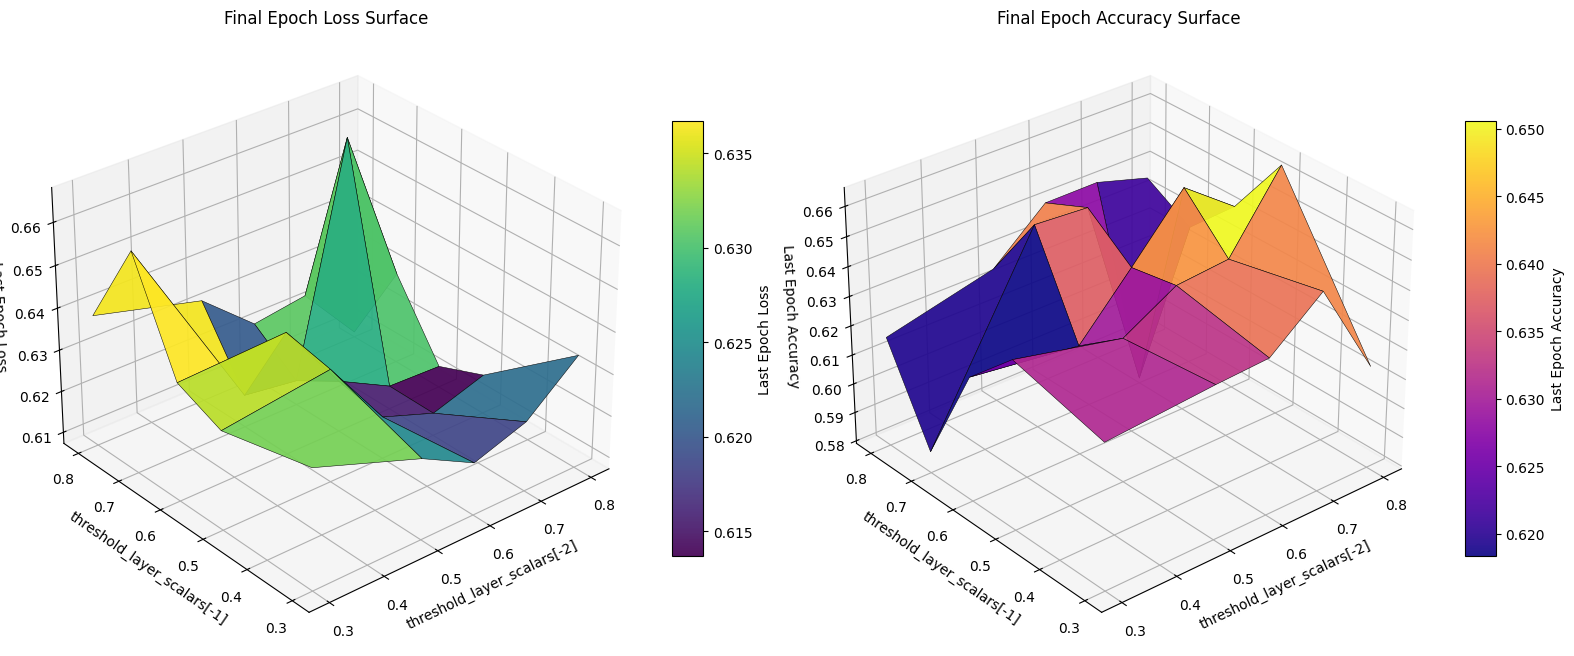

=== Best Parameter Combination by Loss (minimum) ===
threshold_layer_scalars[-2]: 0.8
threshold_layer_scalars[-1]: 0.8
Last Epoch Loss: 0.608455
File: 2-hypr_2026-04-27_08-11-27_e-10_s-25_spatial.json

=== Best Parameter Combination by Accuracy (maximum) ===
threshold_layer_scalars[-2]: 0.8
threshold_layer_scalars[-1]: 0.5
Last Epoch Accuracy: 0.664400
File: 2-hypr_2026-04-27_08-06-02_e-10_s-25_spatial.json

Accuracy key(s) used: ['epoch_train_accuracy']


In [4]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Build two 3D surfaces over the last two threshold_layer_scalars values:
# one for final-epoch loss and one for final-epoch accuracy.
import json
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

files = sorted(glob('../output_results/E2/hypr-2/2-hypr_*.json'))
if not files:
    raise FileNotFoundError('No matching files found in ../output_results/E2')

# (scalar_m2, scalar_m1, last_loss, last_acc, file_name, acc_key_used)
records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    threshold_layer_scalars = training_config.get('threshold_layer_scalars')
    epoch_losses = results.get('epoch_train_loss', [])

    threshold_layer_scalars = list(map(float, map(str.strip, threshold_layer_scalars.strip("[]").split(","))))
    if not isinstance(threshold_layer_scalars, list) or len(threshold_layer_scalars) < 2 or not epoch_losses:
        continue

    # Use the last two values from threshold_layer_scalars as X/Y axes.
    scalar_m2 = float(threshold_layer_scalars[-2])
    scalar_m1 = float(threshold_layer_scalars[-1])
    last_loss = float(epoch_losses[-1])

    # Try common accuracy series names and use the first valid one.
    accuracy_key_candidates = [
        'epoch_train_accuracy',
        'epoch_accuracy',
        'epoch_val_accuracy',
        'epoch_test_accuracy',
    ]
    last_acc = None
    acc_key_used = None
    for key in accuracy_key_candidates:
        series = results.get(key, [])
        if isinstance(series, list) and len(series) > 0:
            last_acc = float(series[-1])
            acc_key_used = key
            break

    if last_acc is None:
        continue

    records.append((scalar_m2, scalar_m1, last_loss, last_acc, Path(file).name, acc_key_used))

if not records:
    raise ValueError(
        'No valid records found with threshold_layer_scalars (len>=2), epoch_train_loss, and an accuracy series.'
    )

x_vals = sorted({r[0] for r in records})
y_vals = sorted({r[1] for r in records})

X, Y = np.meshgrid(x_vals, y_vals)
Z_loss = np.full_like(X, np.nan, dtype=float)
Z_acc = np.full_like(X, np.nan, dtype=float)

for scalar_m2, scalar_m1, loss, acc, _, _ in records:
    x_idx = x_vals.index(scalar_m2)
    y_idx = y_vals.index(scalar_m1)
    Z_loss[y_idx, x_idx] = loss
    Z_acc[y_idx, x_idx] = acc

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

surf1 = ax1.plot_surface(X, Y, Z_loss, cmap='viridis', edgecolor='k', linewidth=0.35, alpha=0.92)
fig.colorbar(surf1, ax=ax1, shrink=0.65, aspect=14, label='Last Epoch Loss')
ax1.set_title('Final Epoch Loss Surface')
ax1.set_xlabel('threshold_layer_scalars[-2]')
ax1.set_ylabel('threshold_layer_scalars[-1]')
ax1.set_zlabel('Last Epoch Loss')
ax1.view_init(elev=30, azim=-130)

surf2 = ax2.plot_surface(X, Y, Z_acc, cmap='plasma', edgecolor='k', linewidth=0.35, alpha=0.92)
fig.colorbar(surf2, ax=ax2, shrink=0.65, aspect=14, label='Last Epoch Accuracy')
ax2.set_title('Final Epoch Accuracy Surface')
ax2.set_xlabel('threshold_layer_scalars[-2]')
ax2.set_ylabel('threshold_layer_scalars[-1]')
ax2.set_zlabel('Last Epoch Accuracy')
ax2.view_init(elev=30, azim=-130)

plt.tight_layout()
plt.show()

best_loss_record = min(records, key=lambda r: r[2])
best_acc_record = max(records, key=lambda r: r[3])

print('=== Best Parameter Combination by Loss (minimum) ===')
print(f'threshold_layer_scalars[-2]: {best_loss_record[0]}')
print(f'threshold_layer_scalars[-1]: {best_loss_record[1]}')
print(f'Last Epoch Loss: {best_loss_record[2]:.6f}')
print(f'File: {best_loss_record[4]}')

print('\n=== Best Parameter Combination by Accuracy (maximum) ===')
print(f'threshold_layer_scalars[-2]: {best_acc_record[0]}')
print(f'threshold_layer_scalars[-1]: {best_acc_record[1]}')
print(f'Last Epoch Accuracy: {best_acc_record[3]:.6f}')
print(f'File: {best_acc_record[4]}')

used_acc_keys = sorted({r[5] for r in records})
print(f'\nAccuracy key(s) used: {used_acc_keys}')